## Ссылка на диск с картированными чтениями


| | SRA accession  | Stage    |
|---:|:-------------|:-----------|
| 1 | SRR5836473  | 8 cell       |
| 2 | SRR3824222 | Epiblast    |
| 3 | SRR5836475  | ICM       |


[Bam-файлы и отчеты](https://drive.google.com/drive/folders/1hGzGjuUZNLIeUsCdSxbEzgthcV_BaqMw?usp=sharing)

Создадим нужные папки

In [5]:
# основная папка
!mkdir -p bismark

!mkdir -p bismark/ref_genome
!mkdir -p bismark/fastqc
!mkdir -p bismark/trimmed

# Первая часть

## Установка FastQC

In [1]:
!wget https://www.bioinformatics.babraham.ac.uk/projects/fastqc/fastqc_v0.11.9.zip
!unzip fastqc_v0.11.9.zip
!chmod a+x FastQC/fastqc

--2025-02-12 09:19:21--  https://www.bioinformatics.babraham.ac.uk/projects/fastqc/fastqc_v0.11.9.zip
Resolving www.bioinformatics.babraham.ac.uk (www.bioinformatics.babraham.ac.uk)... 149.155.133.4
Connecting to www.bioinformatics.babraham.ac.uk (www.bioinformatics.babraham.ac.uk)|149.155.133.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10249221 (9.8M) [application/zip]
Saving to: ‘fastqc_v0.11.9.zip’

fastqc_v0.11.9.zip  100%[===================>]   9.77M  7.27MB/s    in 1.3s    

2025-02-12 09:19:23 (7.27 MB/s) - ‘fastqc_v0.11.9.zip’ saved [10249221/10249221]

Archive:  fastqc_v0.11.9.zip
  inflating: FastQC/cisd-jhdf5.jar   
   creating: FastQC/Configuration/
  inflating: FastQC/Configuration/adapter_list.txt  
  inflating: FastQC/Configuration/contaminant_list.txt  
  inflating: FastQC/Configuration/limits.txt  
  inflating: FastQC/fastqc           
  inflating: FastQC/fastqc_icon.ico  
   creating: FastQC/Help/
   creating: FastQC/Help/1 Introductio

## Установка Bismark с зависимостями (+bowtie2, samtools)

In [2]:
! pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:13
🔁 Restarting kernel...


In [ ]:
import condacolab
condacolab.check()

In [2]:
! conda install -c bioconda bismark

Channels:
 - bioconda
 - conda-forge
Platform: linux-64
Solving environment: | / - done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - bismark


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    bismark-0.24.2             |       hdfd78af_0         7.7 MB  bioconda
    bowtie2-2.5.4              |       he96a11b_5        14.3 MB  bioconda
    ca-certificates-2025.1.31  |       hbcca054_0         154 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    coreutils-8.25             |                1         9.1 MB  bioconda
    hisat2-2.2.1               |       h503566f_8        15.9 MB  bioconda
    htslib-1.21                |       h566b1c6_1         3.0 MB  bioconda
    libdeflate-1.23            |       h4ddbbb0_0          71 KB  conda-forge
    minimap2-2.1.1             |                0      

In [3]:
! samtools view


Usage: samtools view [options] <in.bam>|<in.sam>|<in.cram> [region ...]

Output options:
  -b, --bam                  Output BAM
  -C, --cram                 Output CRAM (requires -T)
  -1, --fast                 Use fast BAM compression (and default to --bam)
  -u, --uncompressed         Uncompressed BAM output (and default to --bam)
  -h, --with-header          Include header in SAM output
  -H, --header-only          Print SAM header only (no alignments)
      --no-header            Print SAM alignment records only [default]
  -c, --count                Print only the count of matching records
  -o, --output FILE          Write output to FILE [standard output]
  -U, --unoutput FILE, --output-unselected FILE
                             Output reads not selected by filters to FILE
  -p, --unmap                Set flag to UNMAP on reads not selected
                             then write to output file.
  -P, --fetch-pairs          Retrieve complete pairs even when outside of region

1. Скачиваем чтения из SRA с помощью SRAtoolkit или любым другим способом

2. Индексируем геном

3. Строим выравнивание

(Описание шагов 2-3 см https://www.bioinformatics.babraham.ac.uk/projects/bismark/Bismark_User_Guide.pdf)



Можно получать данные секвенировия с ENA. Например, https://www.ebi.ac.uk/ena/browser/view/SRR5836473

## но не нужно! Файлы там очень большие

In [4]:
! wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR583/003/SRR5836473/SRR5836473_1.fastq.gz
#! wget ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR583/003/SRR5836473/SRR5836473_2.fastq.gz

--2025-02-12 09:23:44--  ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR583/003/SRR5836473/SRR5836473_1.fastq.gz
           => ‘SRR5836473_1.fastq.gz’
Resolving ftp.sra.ebi.ac.uk (ftp.sra.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.sra.ebi.ac.uk (ftp.sra.ebi.ac.uk)|193.62.193.165|:21... connected.
Error in server response. Closing.
Retrying.

--2025-02-12 09:23:45--  ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR583/003/SRR5836473/SRR5836473_1.fastq.gz
  (try: 2) => ‘SRR5836473_1.fastq.gz’
Connecting to ftp.sra.ebi.ac.uk (ftp.sra.ebi.ac.uk)|193.62.193.165|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /vol1/fastq/SRR583/003/SRR5836473 ... done.
==> SIZE SRR5836473_1.fastq.gz ... 6856386252
==> PASV ... done.    ==> RETR SRR5836473_1.fastq.gz ... done.
Length: 6856386252 (6.4G) (unauthoritative)

SRR5836473_1.fastq. 100%[===================>]   6.38G  29.7MB/s    in 4m 26s  

2025-02-12 09:28:17 (24.6 MB/s) - ‘SRR5836

In [7]:
!mv *.fastq.gz bismark/fastqc

In [8]:
!gzip -dk bismark/fastqc/SRR5836473_1.fastq.gz

In [9]:
!./FastQC/fastqc -o bismark/fastqc bismark/fastqc/SRR5836473_1.fastq

Started analysis of SRR5836473_1.fastq
Approx 5% complete for SRR5836473_1.fastq
Approx 10% complete for SRR5836473_1.fastq
Approx 15% complete for SRR5836473_1.fastq
Approx 20% complete for SRR5836473_1.fastq
Approx 25% complete for SRR5836473_1.fastq
Approx 30% complete for SRR5836473_1.fastq
Approx 35% complete for SRR5836473_1.fastq
Approx 40% complete for SRR5836473_1.fastq
Approx 45% complete for SRR5836473_1.fastq
Approx 50% complete for SRR5836473_1.fastq
Approx 55% complete for SRR5836473_1.fastq
Approx 60% complete for SRR5836473_1.fastq
Approx 65% complete for SRR5836473_1.fastq
Approx 70% complete for SRR5836473_1.fastq
Approx 75% complete for SRR5836473_1.fastq
Approx 80% complete for SRR5836473_1.fastq
Approx 85% complete for SRR5836473_1.fastq
Approx 90% complete for SRR5836473_1.fastq
Approx 95% complete for SRR5836473_1.fastq
Analysis complete for SRR5836473_1.fastq


## Внимание!

Т.к. вычислительные мощности нужны большие, то этот шаг был сделан за вас.
 Достаточно скачать выравнивания с диска https://drive.google.com/drive/folders/1hGzGjuUZNLIeUsCdSxbEzgthcV_BaqMw?usp=sharing или с сервера майнора)

In [10]:
!gdown 1hGzGjuUZNLIeUsCdSxbEzgthcV_BaqMw --folder

Retrieving folder contents
Processing file 1jvj2-mUd7wyeg7nK-BbzgMvoEiudL2M7 checksum.md5
Processing file 1RC6FJEmdWwz8iGwBTJdEcf08wwHHyp1x SRR3824222_1_bismark_bt2_PE_report.txt
Processing file 1vZUsitBBYAYaVHbfonRuoHEK_toNZnN5 SRR3824222_1_bismark_bt2_pe.bam
Processing file 1ybuIMaW1BWdz-ehkzg7BmlZVWu4R6pte SRR5836473_1_bismark_bt2_PE_report.txt
Processing file 1h8kqppLRjNoK2uwcnXfK7iQbe_sXQmor SRR5836473_1_bismark_bt2_pe.bam
Processing file 1L-kZURPu5A7QHxEz8d2pnH-cfaWlYggP SRR5836475_1_bismark_bt2_PE_report.txt
Processing file 1QE-3m9IoJehidSrLM7Npg8larZ4Tt1Ls SRR5836475_1_bismark_bt2_pe.bam
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1jvj2-mUd7wyeg7nK-BbzgMvoEiudL2M7
To: /content/HW1/checksum.md5
100% 198/198 [00:00<00:00, 514kB/s]
Downloading...
From: https://drive.google.com/uc?id=1RC6FJEmdWwz8iGwBTJdEcf08wwHHyp1x
To: /content/HW1/SRR3824222_1_bismark_bt2_PE_report.tx

In [11]:
! ls -lh

total 9.9M
drwxr-xr-x 5 root root 4.0K Feb 12 09:28 bismark
-rw-r--r-- 1 root root  21K Feb 12 09:20 condacolab_install.log
drwxr-xr-x 8 root root 4.0K Feb 12 09:19 FastQC
-rw-r--r-- 1 root root 9.8M Jan 15  2020 fastqc_v0.11.9.zip
drwxr-xr-x 2 root root 4.0K Feb 12 11:19 HW1
drwxr-xr-x 1 root root 4.0K Feb 10 14:25 sample_data


In [13]:
!samtools view HW1/SRR5836473_1_bismark_bt2_pe.bam | head
!samtools view HW1/SRR5836475_1_bismark_bt2_pe.bam | head
!samtools view HW1/SRR3824222_1_bismark_bt2_pe.bam | head

SRR5836473.41_41_length=140	99	chr11	40076664	0	140M	=	40076703	178	AATTTTTTTGGGGATTGTATTGAATTTGTAGATTGTTTTTGGTAAGAGAGTTATTTTTATTATATTGATTTTGTTAATTTATGAATATGGGAGATTTTTTTATTTTTTGAGATTTTTTTTAATTTTTTTTTTTAGAGATT	KKKKKKKKKKKKKKKFKKKKKKKKKKKKKKFKKKKKKKKKFKKKKKKKKKFKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKF7<77FF	NM:i:28	MD:Z:6G0A9C7C9C6C4T2C0C7C9C0C2C0C3C0C5C9C3C0C2C2C6C2C8C3C2C5C1	XM:Z:.................h.......x.........h......h.......hh.......h.........hx..hh...hh.....h.........h...hh..h..x......h..h........h...h..x.....h.	XR:Z:CT	XG:Z:CT
SRR5836473.41_41_length=140	147	chr11	40076703	0	139M	=	40076664	-178	TGGTAAGAGAGTTATTTTTATTATATTGATTTTGTTAATTTATGAATATGGGAGATTTTTTTATTTTTTGAGATTTTTTTTAATTTTTTTTTTTAGAGATTTGAAGTTTTTATTATATAGATTTTTTATTTTTTTAGTG	KKKKKAAFFFKKKKKKKKKKKKKFFKKKKKKKKKKFAFKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKFKKKKKKKKKKKKFKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK	NM:i:31	MD:Z:3C4T2C0C7C9C0C2C0C3C0C5C9C3C0C2C2C6C2C8C3C2C5C8C4C3A4C

In [14]:
!mkdir sorted

In [15]:
!samtools sort HW1/SRR5836473_1_bismark_bt2_pe.bam -o sorted/sorted_8cell.bam
!samtools sort HW1/SRR5836475_1_bismark_bt2_pe.bam -o sorted/sorted_icm.bam
!samtools sort HW1/SRR3824222_1_bismark_bt2_pe.bam -o sorted/sorted_epiblast.bam

[bam_sort_core] merging from 4 files and 1 in-memory blocks...
[bam_sort_core] merging from 5 files and 1 in-memory blocks...
[bam_sort_core] merging from 9 files and 1 in-memory blocks...


In [17]:
!samtools index sorted/sorted_8cell.bam
!samtools index sorted/sorted_epiblast.bam
!samtools index sorted/sorted_icm.bam

Сколько ридов закартировалось на регион 11347700-11367700 в образцах?

In [19]:
! samtools view sorted/sorted_8cell.bam chr11:11347700-11367700 | cut -f1 | sort -u | wc -l
! samtools view sorted/sorted_epiblast.bam chr11:11347700-11367700 | cut -f1 | sort -u | wc -l
! samtools view sorted/sorted_icm.bam chr11:11347700-11367700 | cut -f1 | sort -u | wc -l

551
1344
797


Сколько ридов закартировалось на регион 40185800-40195800 в образцах?

In [20]:
! samtools view sorted/sorted_8cell.bam chr11:40185800-40195800 | cut -f1 | sort -u | wc -l
! samtools view sorted/sorted_epiblast.bam chr11:40185800-40195800 | cut -f1 | sort -u | wc -l
! samtools view sorted/sorted_icm.bam chr11:40185800-40195800 | cut -f1 | sort -u | wc -l

194
565
274


In [21]:
import pandas as pd

df = pd.DataFrame({
        'Образцы': ['8cell', 'epiblast', 'ICM'],
        'chr11:11347700-11367700': [551, 1344, 797],
        'chr11:40185800-40195800': [194, 565, 274]
     })
df

,Образцы,chr11:11347700-11367700,chr11:40185800-40195800
0,8cell,551,194
1,epiblast,1344,565
2,ICM,797,274


Дедупликация

In [22]:
! deduplicate_bismark  --bam  --paired  -o bismark/trimmed/s_SRR5836473_1_bismark_bt2_pe.bam HW1/SRR5836473_1_bismark_bt2_pe.bam
! deduplicate_bismark  --bam  --paired  -o bismark/trimmed/s_SRR5836475_1_bismark_bt2_pe.bam HW1/SRR5836475_1_bismark_bt2_pe.bam
! deduplicate_bismark  --bam  --paired  -o bismark/trimmed/s_SRR3824222_1_bismark_bt2_pe.bam HW1/SRR3824222_1_bismark_bt2_pe.bam

Output filename was given as: bismark/trimmed/s_SRR5836473_1_bismark_bt2_pe.bam
Processing paired-end Bismark output file(s) (SAM format):
HW1/SRR5836473_1_bismark_bt2_pe.bam


If there are several alignments to a single position in the genome the first alignment will be chosen. Since the input files are not in any way sorted this is a near-enough random selection of reads.

Checking file >>HW1/SRR5836473_1_bismark_bt2_pe.bam<< for signs of file truncation...



Now testing Bismark result file HW1/SRR5836473_1_bismark_bt2_pe.bam for positional sorting (which would be bad...)	...passed!
Output file is: s_SRR5836473_1_bismark_bt2_pe.deduplicated.bam

skipping header line:	@HD	VN:1.0	SO:unsorted
skipping header line:	@SQ	SN:chr11	LN:121973369
skipping header line:	@PG	ID:Bismark	VN:v0.24.2	CL:"bismark --genome_folder /mnt/cache-1/for_minor/mm39_11/ -q --non_directional -parallel 10 -1 SRR3824222_1.fq,SRR5836473_1.fq,SRR5836473_1.fq -2 SRR3824222_2.fq,SRR5836473_2.fq,SRR5836473_2.fq"
skipp

In [23]:
!mv s_* bismark/trimmed

In [24]:
! ls

bismark  condacolab_install.log  FastQC  fastqc_v0.11.9.zip  HW1  sample_data  sorted


In [25]:
a = pd.DataFrame({
        'Образцы WGBS': ['8cell', 'epiblast', 'ICM'],
        'Сколько процентов прочтений дуплицированно в каждом из образцов': [18.28, 2.91, 9.07],
     })
a

,Образцы WGBS,Сколько процентов прочтений дуплицированно в каждом из образцов
0,8cell,18.28
1,epiblast,2.91
2,ICM,9.07


11-ю хромосому мыши можно скачать с UCSC (сборка mm39)

In [26]:
import requests
from google.colab import files

url = "https://hgdownload.soe.ucsc.edu/goldenPath/mm39/chromosomes/chr11.fa.gz"
response = requests.get(url)

with open("chr11.fa.gz", "wb") as file:
    file.write(response.content)

files.download("chr11.fa.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
!gzip -dk chr11.fa.gz

In [28]:
!mv chr11* bismark/ref_genome

Коллинг метилирования

In [29]:
!bismark_methylation_extractor --gzip --bedGraph --cytosine_report --genome_folder bismark/ref_genome/ bismark/trimmed/s_SRR5836473_1_bismark_bt2_pe.deduplicated.bam
!bismark_methylation_extractor --gzip --bedGraph --cytosine_report --genome_folder bismark/ref_genome/ bismark/trimmed/s_SRR5836475_1_bismark_bt2_pe.deduplicated.bam
!bismark_methylation_extractor --gzip --bedGraph --cytosine_report --genome_folder bismark/ref_genome/ bismark/trimmed/s_SRR3824222_1_bismark_bt2_pe.deduplicated.bam


 *** Bismark methylation extractor version v0.24.2 ***

Trying to determine the type of mapping from the SAM header line of file bismark/trimmed/s_SRR5836473_1_bismark_bt2_pe.deduplicated.bam
Treating file(s) as paired-end data (as extracted from @PG line)

Setting option '--no_overlap' since this is (normally) the right thing to do for paired-end data


Setting core usage to single-threaded (default). Consider using --multicore <int> to speed up the extraction process.

Summarising Bismark methylation extractor parameters:
Bismark paired-end SAM format specified (default)
Number of cores to be used: 1
Output will be written to the current directory ('/content')


Summarising bedGraph parameters:
Generating additional output in bedGraph and coverage format
bedGraph format:	<Chromosome> <Start Position> <End Position> <Methylation Percentage>
coverage format:	<Chromosome> <Start Position> <End Position> <Methylation Percentage> <count methylated> <count non-methylated>

Using a cutoff 

In [7]:
!mkdir bismark/calling

In [18]:
! cp bismark/calling/s_icm.deduplication_report.txt ./HW1/SRR5836475_1_bismark_bt2_pe.deduplication_report.txt
! cp bismark/calling/s_icm.deduplicated.M-bias.txt ./HW1/SRR5836475_1_bismark_bt2_pe.deduplicated.M-bias.txt
! cp bismark/calling/s_icm.deduplicated_splitting_report.txt ./HW1/SRR5836475_1_bismark_bt2_pe.deduplicated_splitting_report.txt

! cp bismark/calling/s_epiblast.deduplication_report.txt ./HW1/SRR3824222_1_bismark_bt2_pe.deduplication_report.txt
! cp bismark/calling/s_epiblast.deduplicated.M-bias.txt ./HW1/SRR3824222_1_bismark_bt2_pe.deduplicated.M-bias.txt
! cp bismark/calling/s_epiblast.deduplicated_splitting_report.txt ./HW1/SRR3824222_1_bismark_bt2_pe.deduplicated_splitting_report.txt

! cp bismark/calling/s_8_cell.deduplication_report.txt ./HW1/SRR5836473_1_bismark_bt2_pe.deduplication_report.txt
! cp bismark/calling/s_8_cell.deduplicated.M-bias.txt ./HW1/SRR5836473_1_bismark_bt2_pe.deduplicated.M-bias.txt
! cp bismark/calling/s_8_cell.deduplicated_splitting_report.txt ./HW1/SRR5836473_1_bismark_bt2_pe.deduplicated_splitting_report.txt

Запускаем `bismark2report`

In [19]:
!cd HW1 && bismark2report

Found 3 alignment reports in current directory. Now trying to figure out whether there are corresponding optional reports

Writing Bismark HTML report to >> SRR3824222_1_bismark_bt2_PE_report.html <<

Using the following alignment report:		> SRR3824222_1_bismark_bt2_PE_report.txt <
Processing alignment report SRR3824222_1_bismark_bt2_PE_report.txt ...
Complete

Using the following deduplication report:	> SRR3824222_1_bismark_bt2_pe.deduplication_report.txt <
Processing deduplication report SRR3824222_1_bismark_bt2_pe.deduplication_report.txt ...
Complete

Using the following splitting report:		> SRR3824222_1_bismark_bt2_pe.deduplicated_splitting_report.txt <
Processing splitting report SRR3824222_1_bismark_bt2_pe.deduplicated_splitting_report.txt ...
Complete

Using the following M-bias report:		> SRR3824222_1_bismark_bt2_pe.deduplicated.M-bias.txt <
Processing M-bias report SRR3824222_1_bismark_bt2_pe.deduplicated.M-bias.txt ...
Complete

No nucleotide coverage report file specified, 

In [22]:
! ls bismark/calling/*bedGraph.gz | xargs -tI{} gzip -d {}

gzip -d bismark/calling/s_8_cell.deduplicated.bedGraph.gz
gzip -d bismark/calling/s_epiblast.deduplicated.bedGraph.gz
gzip -d bismark/calling/s_icm.deduplicated.bedGraph.gz


In [27]:
!gzip -d bismark/calling/*.deduplicated.bismark.cov.gz

In [23]:
! head bismark/calling/s_8_cell.deduplicated.bedGraph

track type=bedGraph
chr11	3050030	3050031	50
chr11	3050047	3050048	66.6666666666667
chr11	3050048	3050049	50
chr11	3050223	3050224	87.5
chr11	3050224	3050225	53.3333333333333
chr11	3050285	3050286	66.6666666666667
chr11	3050286	3050287	33.3333333333333
chr11	3050309	3050310	62.5
chr11	3050310	3050311	50


In [28]:
! head bismark/calling/s_8_cell.deduplicated.bismark.cov

chr11	3050031	3050031	50	1	1
chr11	3050048	3050048	66.6666666666667	2	1
chr11	3050049	3050049	50	1	1
chr11	3050224	3050224	87.5	7	1
chr11	3050225	3050225	53.3333333333333	8	7
chr11	3050286	3050286	66.6666666666667	6	3
chr11	3050287	3050287	33.3333333333333	5	10
chr11	3050310	3050310	62.5	5	3
chr11	3050311	3050311	50	7	7
chr11	3050349	3050349	55.5555555555556	5	4


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

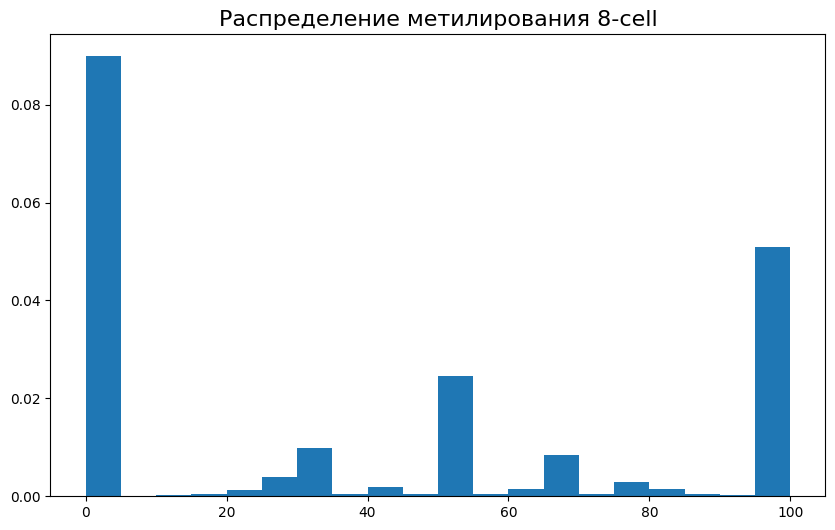

In [18]:
filename = "bismark/calling/s_8_cell.deduplicated.bedGraph"
df = pd.read_csv(filename, delimiter='\t', skiprows=1, header=None)

plt.figure(figsize=[10, 6])
plt.title("Распределение метилирования 8-cell", fontsize=16)
plt.hist(df[3], bins=20, density=True)
plt.show()

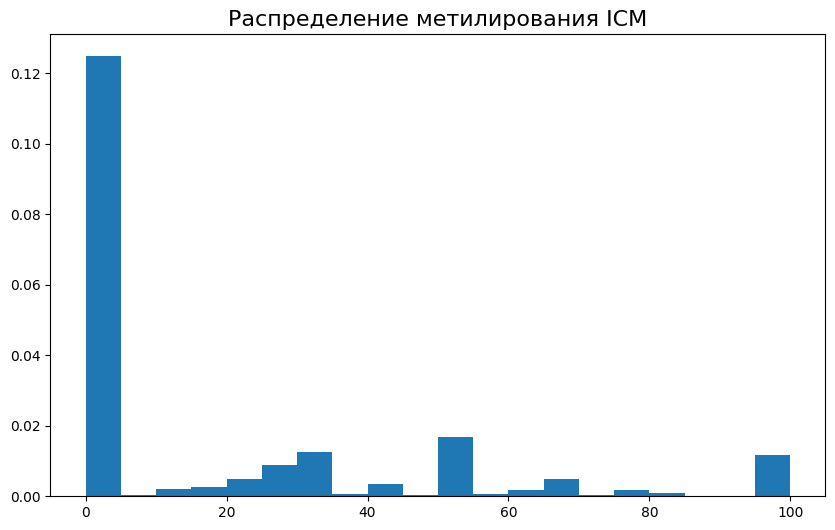

In [20]:
filename3 = "bismark/calling/s_icm.deduplicated.bedGraph"
df3 = pd.read_csv(filename3, delimiter='\t', skiprows=1, header=None)

plt.figure(figsize=[10, 6])
plt.title("Распределение метилирования ICM", fontsize=16)
plt.hist(df3[3], bins=20, density=True)
plt.show()

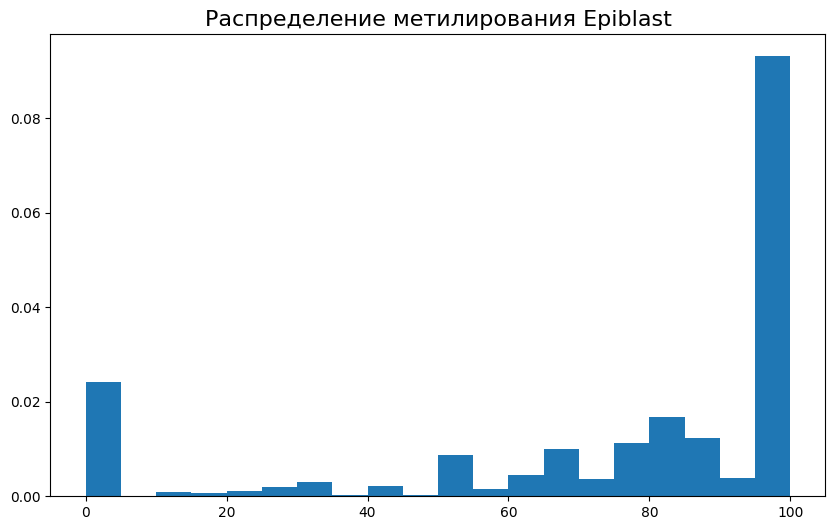

In [19]:
filename2 = "bismark/calling/s_epiblast.deduplicated.bedGraph"
df2 = pd.read_csv(filename2, delimiter='\t', skiprows=1, header=None)

plt.figure(figsize=[10, 6])
plt.title("Распределение метилирования Epiblast", fontsize=16)
plt.hist(df2[3], bins=20, density=True)
plt.show()

# Вторая часть задания

In [29]:
! pip install pyGenomeTracks

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 92.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.0/26.0 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [1]:
!pip install -U ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.5/825.5 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 874.5/874.5 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.1 MB/s eta 0:00:00


In [1]:
! conda install -c bioconda ucsc-fetchchromsizes

Channels:
 - bioconda
 - conda-forge
Platform: linux-64
Solving environment: \ | / done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 25.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - ucsc-fetchchromsizes


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    libopenssl-static-3.4.1    |       hb9d3cd8_0         2.5 MB  conda-forge
    libpng-1.6.46              |       h943b412_0         285 KB  conda-forge
    mysql-connector-c-6.1.11   |    h659d440_1008         1.2 MB  conda-forge
    ucsc-fetchchromsizes-469   |       h664eb37_1           9 KB  bioconda
    ------------------------------------------------------------
                                           Total:         4.0 MB

The following NEW pa

In [2]:
! fetchChromSizes mm39 > m.chrom.sizes

INFO: trying CURL  for database mm39
url: http://hgdownload.soe.ucsc.edu/goldenPath/mm39/bigZips/mm39.chrom.sizes


In [3]:
! conda install -c bioconda ucsc-bedgraphtobigwig

Channels:
 - bioconda
 - conda-forge
Platform: linux-64
Solving environment: \ | / - done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 25.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - ucsc-bedgraphtobigwig


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ucsc-bedgraphtobigwig-472  |       h664eb37_2         2.0 MB  bioconda
    ------------------------------------------------------------
                                           Total:         2.0 MB

The following NEW packages will be INSTALLED:

  ucsc-bedgraphtobi~ bioconda/linux-64::ucsc-bedgraphtobigwig-472-h664eb37_2 



                                                                        
Preparing transaction: - done
Verifying transa

In [5]:
!apt-get install bedtools

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  bedtools
0 upgraded, 1 newly installed, 0 to remove and 20 not upgraded.
Need to get 563 kB of archives.
After this operation, 1,548 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 bedtools amd64 2.30.0+dfsg-2ubuntu0.1 [563 kB]
Fetched 563 kB in 1s (460 kB/s)
Selecting previously unselected package bedtools.
(Reading database ... 124926 files and directories currently installed.)
Preparing to unpack .../bedtools_2.30.0+dfsg-2ubuntu0.1_amd64.deb ...
Unpacking bedtools (2.30.0+dfsg-2ubuntu0.1) ...
Setting up bedtools (2.30.0+dfsg-2ubuntu0.1) ...


In [6]:
!bedtools genomecov -bg -ibam bismark/trimmed/s_SRR5836473_1_bismark_bt2_pe.deduplicated.bam -g m.chrom.sizes > s_8_cell.cover.bedGraph
!bedtools genomecov -bg -ibam bismark/trimmed/s_SRR5836475_1_bismark_bt2_pe.deduplicated.bam -g m.chrom.sizes > s_icm.cover.bedGraph
!bedtools genomecov -bg -ibam bismark/trimmed/s_SRR3824222_1_bismark_bt2_pe.deduplicated.bam -g m.chrom.sizes > s_epiblast.cover.bedGraph


*****
*****WARNING: Genome (-g) files are ignored when BAM input is provided. 
*****

*****
*****WARNING: Genome (-g) files are ignored when BAM input is provided. 
*****

*****
*****WARNING: Genome (-g) files are ignored when BAM input is provided. 
*****


In [21]:
!mkdir cover
!mv *.cover.bedGraph cover

In [22]:
!bedGraphToBigWig cover/s_8_cell.cover.bedGraph m.chrom.sizes cover/cell8_coverage.bigWig.bw
!bedGraphToBigWig cover/s_icm.cover.bedGraph m.chrom.sizes cover/icm_coverage.bigWig.bw
!bedGraphToBigWig cover/s_epiblast.cover.bedGraph m.chrom.sizes cover/epiblast_coverage.bigWig.bw

In [31]:
! make_tracks_file --trackFiles cover/cell8_coverage.bigWig.bw cover/icm_coverage.bigWig.bw cover/epiblast_coverage.bigWig.bw -o cover/tracks.ini.txt

Adding bigwig file: cover/cell8_coverage.bigWig.bw
Adding bigwig file: cover/icm_coverage.bigWig.bw
Adding bigwig file: cover/epiblast_coverage.bigWig.bw


In [32]:
! pyGenomeTracks --tracks cover/tracks.ini.txt --region chr11:3100030-3500030 -o cover/image_cov.png

INFO:pygenometracks.tracksClass:initialize 1. [x-axis]
INFO:pygenometracks.tracksClass:initialize 2. [spacer]
INFO:pygenometracks.tracksClass:initialize 3. [cell8_coverage.bigWig]
INFO:pygenometracks.tracksClass:initialize 4. [icm_coverage.bigWig]
INFO:pygenometracks.tracksClass:initialize 5. [epiblast_coverage.bigWig]
INFO:pygenometracks.tracksClass:time initializing track(s):
INFO:pygenometracks.tracksClass:0.0029807090759277344
DEBUG:pygenometracks.tracksClass:Figure size in cm is 40 x 8.909574468085108. Dpi is set to 72

INFO:pygenometracks.tracksClass:plotting 1. [x-axis]
INFO:pygenometracks.tracksClass:plotting 2. [spacer]
INFO:pygenometracks.tracksClass:plotting 3. [cell8_coverage.bigWig]
INFO:pygenometracks.tracksClass:plotting 4. [icm_coverage.bigWig]
INFO:pygenometracks.tracksClass:plotting 5. [epiblast_coverage.bigWig]


In [26]:
! bedGraphToBigWig bismark/calling/s_8_cell.deduplicated.bedGraph m.chrom.sizes cover/cell8_methylation.bigWig.bw
! bedGraphToBigWig bismark/calling/s_icm.deduplicated.bedGraph m.chrom.sizes cover/icm_methylation.bigWig.bw
! bedGraphToBigWig bismark/calling/s_epiblast.deduplicated.bedGraph m.chrom.sizes cover/epiblast_methylation.bigWig.bw

In [33]:
! make_tracks_file --trackFiles cover/cell8_methylation.bigWig.bw cover/icm_methylation.bigWig.bw cover/epiblast_methylation.bigWig.bw -o cover/tracks.ini

Adding bigwig file: cover/cell8_methylation.bigWig.bw
Adding bigwig file: cover/icm_methylation.bigWig.bw
Adding bigwig file: cover/epiblast_methylation.bigWig.bw


In [34]:
! pyGenomeTracks --tracks cover/tracks.ini --region chr11:3100030-3500030 -o cover/image_meth.png

INFO:pygenometracks.tracksClass:initialize 1. [x-axis]
INFO:pygenometracks.tracksClass:initialize 2. [spacer]
INFO:pygenometracks.tracksClass:initialize 3. [cell8_methylation.bigWig]
INFO:pygenometracks.tracksClass:initialize 4. [icm_methylation.bigWig]
INFO:pygenometracks.tracksClass:initialize 5. [epiblast_methylation.bigWig]
INFO:pygenometracks.tracksClass:time initializing track(s):
INFO:pygenometracks.tracksClass:0.003166675567626953
DEBUG:pygenometracks.tracksClass:Figure size in cm is 40 x 8.909574468085108. Dpi is set to 72

INFO:pygenometracks.tracksClass:plotting 1. [x-axis]
INFO:pygenometracks.tracksClass:plotting 2. [spacer]
INFO:pygenometracks.tracksClass:plotting 3. [cell8_methylation.bigWig]
INFO:pygenometracks.tracksClass:plotting 4. [icm_methylation.bigWig]
INFO:pygenometracks.tracksClass:plotting 5. [epiblast_methylation.bigWig]


# Часть 3

In [43]:
! conda install -y -c conda-forge -c bioconda metilene

Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: \ | / - \ | / - done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 25.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - metilene


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _r-mutex-1.0.1             |      anacondar_1           3 KB  conda-forge
    bedtools-2.31.1            |       h13024bc_3         1.5 MB  bioconda
    binutils_impl_linux-64-2.43|       h4bf12b8_2         5.4 MB  conda-forge
    bwidget-1.10.1             |       ha770c72_0         126 KB  conda-forge
    cairo-1.18.2               |       h3394656_1         956 KB  conda-forge
    curl-8.11.1                |       h332b0f4_0         171 KB 

In [35]:
import pandas as pd
import subprocess
from scipy.stats import ttest_ind
import numpy as np

Функция для объединения данных из всех образцов в формат для metilene

In [36]:
def prepare_metilene_input(samples, output_file):
    dfs = []
    for sample in samples:
        df = pd.read_csv(sample['file'], sep='\t',
                        names=['chr', 'start', 'end', 'percentage', 'methylated', 'unmethylated'])
        df['ratio'] = df['percentage'] / 100
        dfs.append(df[['chr', 'start', 'ratio']])

    # объединение данных с добавлением префиксов
    merged = dfs[0]
    merged.columns = ['chr', 'start', f"{samples[0]['group']}_1"]
    for i, (sample, df) in enumerate(zip(samples[1:], dfs[1:]), start=2):
        df.columns = ['chr', 'start', f"{sample['group']}_{i}"]
        merged = pd.merge(merged, df, on=['chr', 'start'], how='outer')

    merged.fillna(0, inplace=True)
    merged.to_csv(output_file, sep='\t', index=False)

Функция для запуска metilene для поиска DMC

In [37]:
def search_dmc(input_file, group_a, group_b, output_file, is_dmr=False):
    command = [
        "metilene",
        "-a", group_a,
        "-b", group_b,
        "-t", "4"
    ]

    if not is_dmr:
        command += ["-f", "3"]  # DMC флаг
    command += [input_file]

    with open(output_file, 'w') as f:
        subprocess.run(command, stdout=f, check=True)

Конфигурация анализа

In [38]:
samples = [
    {'file': 'bismark/calling/s_8_cell.deduplicated.bismark.cov', 'group': 'g1'},
    {'file': 'bismark/calling/s_icm.deduplicated.bismark.cov', 'group': 'g2'},
    {'file': 'bismark/calling/s_epiblast.deduplicated.bismark.cov', 'group': 'g3'}
]

Подготовка данных

In [39]:
!mkdir dmr

In [40]:
metilene_input = "dmr/combined_data.txt"
prepare_metilene_input(samples, metilene_input)

Анализ DMR

In [44]:
search_dmc(metilene_input, "g1", "g2", "dmr/dmr_1-2.txt", is_dmr=True)
search_dmc(metilene_input, "g2", "g3", "dmr/dmr_2-3.txt", is_dmr=True)
search_dmc(metilene_input, "g1", "g3", "dmr/dmr_1-3.txt", is_dmr=True)

Анализ DMC

In [45]:
search_dmc(metilene_input, "g1", "g2", "dmr/dmc_1-2.txt")
search_dmc(metilene_input, "g2", "g3", "dmr/dmc_2-3.txt")
search_dmc(metilene_input, "g1", "g3", "dmr/dmc_1-3.txt")

# 4-я часть

In [46]:
! wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/635/GCF_000001635.27_GRCm39/GCF_000001635.27_GRCm39_feature_table.txt.gz
! gunzip GCF_000001635.27_GRCm39_feature_table.txt.gz

--2025-02-12 17:38:27--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/635/GCF_000001635.27_GRCm39/GCF_000001635.27_GRCm39_feature_table.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.7, 130.14.250.10, 130.14.250.11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.7|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6572982 (6.3M) [application/x-gzip]
Saving to: ‘GCF_000001635.27_GRCm39_feature_table.txt.gz’

GCF_000001635.27_GR 100%[===================>]   6.27M  11.9MB/s    in 0.5s    

2025-02-12 17:38:28 (11.9 MB/s) - ‘GCF_000001635.27_GRCm39_feature_table.txt.gz’ saved [6572982/6572982]



In [48]:
!head GCF_000001635.27_GRCm39_feature_table.txt

# feature	class	assembly	assembly_unit	seq_type	chromosome	genomic_accession	start	end	strand	product_accession	non-redundant_refseq	related_accession	name	symbol	GeneID	locus_tag	feature_interval_length	product_length	attributes
gene	snRNA	GCF_000001635.27	C57BL/6J	chromosome	1	NC_000067.7	3172239	3172348	+				predicted gene, 26206	Gm26206	115487594		110		
ncRNA	snRNA	GCF_000001635.27	C57BL/6J	chromosome	1	NC_000067.7	3172239	3172348	+	XR_004936710.1			U6 spliceosomal RNA	Gm26206	115487594		110	110	
gene	protein_coding	GCF_000001635.27	C57BL/6J	chromosome	1	NC_000067.7	3269956	3741733	-				X-linked Kx blood group related 4	Xkr4	497097		471778		
mRNA		GCF_000001635.27	C57BL/6J	chromosome	1	NC_000067.7	3269956	3741733	-	XM_006495550.5		XP_006495613.1	X-linked Kx blood group related 4, transcript variant X1	Xkr4	497097		12274	12274	
mRNA		GCF_000001635.27	C57BL/6J	chromosome	1	NC_000067.7	3284705	3741721	-	NM_001011874.1		NP_001011874.1	X-linked Kx blood group related 4	Xkr4	497097		3634

In [54]:
import csv


a = ''
with open('GCF_000001635.27_GRCm39_feature_table.txt', 'r', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter='\t')
    for row in reader:
        if row[5] == '11' and row[0] == 'gene' and row[19] != 'pseudo':
            a += f'chr11\t{row[7]}\t{row[8]}\t{row[14]}\n'

with open('dmr/a.bed', 'w', encoding='utf-8') as f:
    f.write(a)

In [50]:
! cp dmr/dmr_1-2.txt dmr/dmr_1-2.bed
! cp dmr/dmr_2-3.txt dmr/dmr_2-3.bed
! cp dmr/dmr_1-3.txt dmr/dmr_1-3.bed

In [55]:
! bedtools intersect -a dmr/a.bed -b dmr/dmr_1-2.bed -wa -u > dmr/intersect_1-2.bed
! bedtools intersect -a dmr/a.bed -b dmr/dmr_2-3.bed -wa -u > dmr/intersect_2-3.bed
! bedtools intersect -a dmr/a.bed -b dmr/dmr_1-3.bed -wa -u > dmr/intersect_1-3.bed

In [56]:
!conda install -y gprofiler-official

Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: \ | / - \ | / - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 25.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - gprofiler-official


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    gprofiler-official-1.0.0   |             py_0          13 KB  bioconda
    ------------------------------------------------------------
                                           Total:          13 KB

The following NEW packages will be INSTALLED:

  gprofiler-official bioconda/noarch::gprofiler-official-1.0.0-py_0 



                                                                        
Preparing transaction: - done
Verifyin

In [57]:
from gprofiler import GProfiler


df = pd.read_csv('dmr/intersect_1-2.bed', sep='\t',
                 names=['chr', 'start', 'end', 'gene'])

gp = GProfiler(return_dataframe=True)
profile = gp.profile(organism='mmusculus',
                     query=list(df['gene']))
profile.to_csv('dmr/GO_1-2.csv')

profile

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:CC,GO:0005737,cytoplasm,8.946945e-54,True,"""The contents of a cell excluding the plasma m...",11701,1059,706,27195,0.666667,0.060337,query_1,"[GO:0005622, GO:0110165]"
1,TF,TF:M00716_1,Factor: ZF5; motif: GSGCGCGR; match class: 1,1.066139e-31,True,Factor: ZF5; motif: GSGCGCGR; match class: 1,12044,1008,746,21628,0.740079,0.061940,query_1,[TF:M00716]
2,TF,TF:M00716,Factor: ZF5; motif: GSGCGCGR,4.014117e-29,True,Factor: ZF5; motif: GSGCGCGR,14822,1008,851,21628,0.844246,0.057415,query_1,[TF:M00000]
3,GO:BP,GO:0051179,localization,7.193206e-29,True,"""Any process in which a cell, a substance, or ...",5362,1042,367,26963,0.352207,0.068445,query_1,[GO:0008150]
4,TF,TF:M10209,Factor: E2F-1; motif: GNGGGCGGGRMN,3.660721e-28,True,Factor: E2F-1; motif: GNGGGCGGGRMN,14209,1008,825,21628,0.818452,0.058062,query_1,[TF:M00000]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,GO:BP,GO:0030031,cell projection assembly,4.904096e-02,True,"""Formation of a prolongation or process extend...",602,1042,45,26963,0.043186,0.074751,query_1,"[GO:0022607, GO:0030030]"
674,GO:BP,GO:0050896,response to stimulus,4.910302e-02,True,"""Any process that results in a change in state...",10529,1042,471,26963,0.452015,0.044734,query_1,[GO:0008150]
675,TF,TF:M07475_1,Factor: Tbx5; motif: SNAGGTGTGRNGGSS; match cl...,4.940128e-02,True,Factor: Tbx5; motif: SNAGGTGTGRNGGSS; match cl...,1031,1008,77,21628,0.076389,0.074685,query_1,[TF:M07475]
676,GO:BP,GO:0003012,muscle system process,4.976395e-02,True,"""A organ system process carried out at the lev...",440,1042,36,26963,0.034549,0.081818,query_1,[GO:0003008]


In [58]:
df = pd.read_csv('dmr/intersect_2-3.bed', sep='\t',
                 names=['chr', 'start', 'end', 'gene'])

gp = GProfiler(return_dataframe=True)
profile = gp.profile(organism='mmusculus',
            query=list(df['gene']))
profile.to_csv('dmr/GO_2-3.csv')

profile

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:CC,GO:0005737,cytoplasm,1.025957e-30,True,"""The contents of a cell excluding the plasma m...",11701,1582,911,27195,0.575853,0.077857,query_1,"[GO:0005622, GO:0110165]"
1,TF,TF:M01822_1,Factor: CPBP; motif: SNCCCNN; match class: 1,1.113571e-22,True,Factor: CPBP; motif: SNCCCNN; match class: 1,19770,1419,1389,21628,0.978858,0.070258,query_1,[TF:M01822]
2,GO:BP,GO:0051179,localization,7.289032e-20,True,"""Any process in which a cell, a substance, or ...",5362,1567,471,26963,0.300574,0.087840,query_1,[GO:0008150]
3,GO:CC,GO:0005882,intermediate filament,2.669147e-17,True,"""A cytoskeletal structure that forms a distinc...",213,1582,53,27195,0.033502,0.248826,query_1,"[GO:0045111, GO:0099513]"
4,GO:BP,GO:0006810,transport,5.658294e-17,True,"""The directed movement of substances (such as ...",4387,1567,393,26963,0.250798,0.089583,query_1,[GO:0051234]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,TF,TF:M00712_1,Factor: myogenin; motif: RGCAGSTG; match class: 1,4.763311e-02,True,Factor: myogenin; motif: RGCAGSTG; match class: 1,1435,1419,133,21628,0.093728,0.092683,query_1,[TF:M00712]
396,GO:CC,GO:0005876,spindle microtubule,4.802152e-02,True,"""Any microtubule that is part of a mitotic or ...",78,1582,14,27195,0.008850,0.179487,query_1,"[GO:0005819, GO:0005874]"
397,GO:CC,GO:1902494,catalytic complex,4.901722e-02,True,"""A protein complex which is capable of catalyt...",1720,1582,136,27195,0.085967,0.079070,query_1,[GO:0032991]
398,TF,TF:M10301,Factor: MyoD; motif: NCAGCTGTYNCYNNC,4.959342e-02,True,Factor: MyoD; motif: NCAGCTGTYNCYNNC,3549,1419,289,21628,0.203665,0.081431,query_1,[TF:M00000]


In [59]:
df = pd.read_csv('dmr/intersect_1-3.bed', sep='\t',
                 names=['chr', 'start', 'end', 'gene'])

gp = GProfiler(return_dataframe=True)
profile = gp.profile(organism='mmusculus',
            query=list(df['gene']))
profile.to_csv('dmr/GO_1-3.csv')

profile

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:CC,GO:0005737,cytoplasm,9.773171e-34,True,"""The contents of a cell excluding the plasma m...",11701,1467,864,27195,0.588957,0.073840,query_1,"[GO:0005622, GO:0110165]"
1,GO:BP,GO:0051179,localization,2.157751e-23,True,"""Any process in which a cell, a substance, or ...",5362,1450,455,26963,0.313793,0.084856,query_1,[GO:0008150]
2,TF,TF:M01822_1,Factor: CPBP; motif: SNCCCNN; match class: 1,1.391194e-20,True,Factor: CPBP; motif: SNCCCNN; match class: 1,19770,1332,1303,21628,0.978228,0.065908,query_1,[TF:M01822]
3,GO:BP,GO:0006810,transport,1.204709e-19,True,"""The directed movement of substances (such as ...",4387,1450,379,26963,0.261379,0.086392,query_1,[GO:0051234]
4,GO:BP,GO:0051234,establishment of localization,1.705048e-19,True,"""Any process that localizes a substance or cel...",4689,1450,398,26963,0.274483,0.084880,query_1,[GO:0051179]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,TF,TF:M07260,Factor: Ikaros; motif: TGGGAGN,4.897201e-02,True,Factor: Ikaros; motif: TGGGAGN,11411,1332,774,21628,0.581081,0.067829,query_1,[TF:M00000]
404,GO:BP,GO:0002753,cytoplasmic pattern recognition receptor signa...,4.915095e-02,True,"""The series of molecular signals initiated by ...",174,1450,24,26963,0.016552,0.137931,query_1,"[GO:0002221, GO:0030522]"
405,HP,HP:0008392,Subungual hyperkeratosis,4.923885e-02,True,A thickening of the stratum corneum in the reg...,7,353,5,5228,0.014164,0.714286,query_1,"[HP:0000962, HP:0009723]"
406,GO:MF,GO:0140098,"catalytic activity, acting on RNA",4.970059e-02,True,"""Catalytic activity that acts to modify RNA, d...",393,1443,42,25071,0.029106,0.106870,query_1,[GO:0140640]
